# Telling materials apart with composition and structure features

**MS697 AI-driven Materials Development**
`Lecture 3 — Features (compositional and structural fingerprints) for materials`

A notebook that computes, directly, what composition-only features and structure features
each can and cannot tell apart. We start by projecting twelve different compositions with
composition featurizers, to see what each featurizer looks at. We then move to three TiO₂
polymorphs, which share a composition and differ only in structure: the 145 composition
features take exactly the same values for all three and collapse them onto one point, while
structure features pull the three apart. Next comes the reverse case — three prototype
groups whose compositions differ but whose crystal structure is the same
(rutile, perovskite, spinel), five members each — where we compare which structure features
read the crystal structure and gather each group. Finally we project 100 Materials Project
entries with composition features alone, structure features alone, and the two together, to
see whether the entries keep their own places instead of piling up. The last part is a
hands-on section that runs the same procedure on a composition other than TiO₂. Every 2D
projection is a PCA.

## Part 1: Setup

Two cells to run first: one installs the libraries, one downloads the course files.
`py3Dmol` gives the rotatable 3D structures in Parts 3 and 8; without it a static image
is used instead. On Colab both cells have to run again every time the runtime restarts.

In [ ]:
## A leading ! runs a terminal command instead of Python. -q keeps the install output quiet.
!pip install -q matminer pymatgen py3Dmol

In [ ]:
## git clone downloads an entire repository from GitHub. Running it twice is harmless
## -- it just prints "destination path already exists".
!git clone https://github.com/kwongibaek/MS49900-AI4M.git

In [1]:
import sys, gc, warnings, itertools, textwrap
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matminer, pymatgen.core, sklearn
from pymatgen.core import Composition, Structure, Lattice
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
np.set_printoptions(linewidth=140, suppress=True)

# 그림 글자 크기. 기본값(10pt)으로 그리면 슬라이드에 넣을 때 그림이 줄어들면서
# 3~5pt 로 찍혀 읽히지 않는다. 여기서 한 번 올려 두면 fontsize= 를 따로 주지 않은
# 축 눈금·축 이름·범례가 모두 따라오고, 볼드도 여기서 걸린다.
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 11,
    "font.weight": "bold", "axes.titleweight": "bold", "axes.labelweight": "bold",
    "figure.titleweight": "bold",
})

print("python      :", sys.version.split()[0])
print("matminer    :", matminer.__version__)
print("pymatgen    :", pymatgen.core.__version__)
print("scikit-learn:", sklearn.__version__)

python      : 3.11.15
matminer    : 0.10.1
pymatgen    : 2026.5.18
scikit-learn: 1.9.0


### The crystal structure files

Every crystal structure used here was downloaded from the Materials Project and saved as a
CIF file in `Hand-on-session2/data/cif/` of the repository cloned above.

The cell below looks for that folder in a few places and uses the first one it finds, so the
same notebook works on Colab and on your own machine. If it raises `FileNotFoundError`, the
`git clone` cell above has not been run.

In [2]:
from pathlib import Path

CANDIDATES = [
    Path("data/cif"),                                          # next to this notebook
    Path("../data/cif"),
    Path("MS49900-AI4M/Hand-on-session2/data/cif"),            # Colab, after the git clone above
    Path("/content/MS49900-AI4M/Hand-on-session2/data/cif"),
    Path("/content/drive/MyDrive/MS49900-AI4M/Hand-on-session2/data/cif"),
]

CIF_DIR = next((p for p in CANDIDATES if p.is_dir()), None)
if CIF_DIR is None:
    raise FileNotFoundError(
        "Could not find the data/cif folder. Upload the whole study_materials folder "
        "and run again, or add your path to CANDIDATES.")

DATA_DIR = CIF_DIR.parent          # the folder holding the index csv and structure bundles
print("CIF folder :", CIF_DIR.resolve())
print("data folder:", DATA_DIR.resolve())

CIF folder : /home/ehddong11/ai4mat/Week3/feature/study_materials/data/cif
data folder: /home/ehddong11/ai4mat/Week3/feature/study_materials/data


### Shared helpers

Five functions used throughout this notebook. Colab cannot import a local module, so they
stay in the notebook itself.

In [3]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Tolerance of the variance filter. The floating-point residue seen in this notebook is at
# the 1e-12 level, so this is set well above it. A meaningful feature usually has a
# standard deviation above 1e-2.
VAR_TOL = 1e-8


def safe_featurize(featurizer, items):
    """Turn the result of featurize_many into a float matrix, filling gaps with the column median.

    The Voronoi-based featurizers in matminer return a whole row of NaN when one structure
    fails. Dropping the columns that contain a NaN would wipe out most of the features even
    when a single structure failed, so the columns are kept and only the values are filled.

    Returns
    -------
    X : (n_item, n_feature) float array
    n_failed : number of rows that had at least one NaN
    """
    raw = featurizer.featurize_many(items, ignore_errors=True, pbar=False)
    X = np.array([[np.nan if (v is None or isinstance(v, (str, bool))) else float(v)
                   for v in row] for row in raw], dtype=float)
    n_failed = int(np.isnan(X).any(axis=1).sum())
    X = SimpleImputer(strategy="median", keep_empty_features=True).fit_transform(X)
    return X, n_failed


def embed2d(X, tol=VAR_TOL, seed=0, return_pca=False):
    """Drop the columns without variance, standardise, and project to 2D with PCA.

    Every 2D projection in this notebook is a PCA. PCA is a linear map, and it tells us what
    fraction of the original variance the two components carry. t-SNE and UMAP preserve
    local structure instead, and rearrange the points non-linearly.

    Raises
    ------
    ValueError : when fewer than two columns vary, which means this feature set does not
                 tell the given inputs apart at all.
    """
    keep = np.nanstd(X, axis=0) > tol
    Xv = X[:, keep]
    if Xv.shape[1] < 2:
        raise ValueError(
            f"only {Xv.shape[1]} column(s) vary (tol={tol:g}, {X.shape[1]} columns in total). "
            "A 2D embedding cannot be built.")
    Xs = StandardScaler().fit_transform(Xv)
    pca = PCA(n_components=2, random_state=seed)
    Z = pca.fit_transform(Xs)
    if return_pca:
        return Z, int(keep.sum()), pca
    return Z, int(keep.sum())


# All text inside the figures is English. The default Colab environment has no CJK font,
# so Korean characters would come out as boxes.
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860",
           "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]


def plot_by_group(Z, groups, ax=None, title="", legend=True, s_pt=45, annot=None):
    """Scatter of a 2D projection. Same group, same colour; annot adds a label per point."""
    groups = np.asarray(groups)
    if ax is None:
        _, ax = plt.subplots(figsize=(5.4, 4.6))
    for i, g in enumerate(sorted(set(groups))):
        m = groups == g
        ax.scatter(Z[m, 0], Z[m, 1], s=s_pt, alpha=0.85, color=PALETTE[i % len(PALETTE)],
                   label=str(g), edgecolor="black", linewidth=0.4)
    if annot is not None:
        for (x, y), name in zip(Z, annot):
            ax.annotate(str(name), (x, y), fontsize=9,
                        textcoords="offset points", xytext=(5, 4))
    ax.margins(0.18)
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_title(title, fontsize=14)
    if legend:
        ax.legend(fontsize=11, loc="best", framealpha=0.85)
    ax.grid(alpha=0.25, lw=0.5)
    return ax


def pca_panels(sets, groups, ncol=3, size=(4.3, 3.9), annot=None, s_pt=45, legend_at=0):
    """Project each {name: feature matrix} to 2D with PCA and draw them as a grid.

    The panel title carries the number of features and the fraction of the variance the two
    components explain. When fewer than two columns vary there is nothing to project onto,
    and the panel says so.
    """
    n = len(sets)
    nrow = int(np.ceil(n / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(size[0] * ncol, size[1] * nrow))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes[n:]:
        ax.axis("off")
    for k, (name, X) in enumerate(sets.items()):
        ax = axes[k]
        try:
            Z, n_kept, pca = embed2d(X, return_pca=True)
        except ValueError:
            ax.text(0.5, 0.5, "no 2D projection\n(varying columns < 2)",
                    ha="center", va="center", fontsize=13)
            ax.set_title(f"{name}\n{X.shape[1]} features", fontsize=14)
            ax.set_xticks([]); ax.set_yticks([])
            continue
        ev = pca.explained_variance_ratio_.sum()
        plot_by_group(Z, groups, ax=ax, s_pt=s_pt, annot=annot,
                      legend=(k == legend_at),
                      title=f"{name}\n{X.shape[1]} features, PC1+PC2 = {ev:.2f}")
    fig.tight_layout()
    return fig, axes


def show_vector(X, feature_names, item_names, head=8, tail=4, decimals=4):
    """Transpose the feature matrix to rows = features, columns = materials, and show the ends."""
    df = pd.DataFrame(X.T, index=feature_names, columns=item_names)
    if len(df) <= head + tail:
        return df.round(decimals)
    gap = pd.DataFrame([["..."] * df.shape[1]],
                       index=[f"... ({len(df) - head - tail} more)"], columns=df.columns)
    return pd.concat([df.head(head).round(decimals), gap, df.tail(tail).round(decimals)])


print("helpers defined")

helpers defined


## Part 2: Telling different compositions apart with composition features

A composition featurizer only takes a `Composition`. It does not see where the atoms sit,
only which elements are present and in what proportion.

We start with twelve different compositions: oxides, sulfides, halides, nitrides,
semiconductors and a metal. The family is decided by the elements in the formula, so it is
not a label assigned by hand.

In [4]:
from pymatgen.core import Composition

COMP_SET = ["MgO", "Al2O3", "TiO2", "SiO2", "ZnS", "MoS2",
            "NaCl", "CaF2", "GaN", "TiN", "GaAs", "Cu"]

ANION = [("O", "oxide"), ("S", "sulfide"), ("F", "halide"), ("Cl", "halide"),
         ("N", "nitride"), ("As", "pnictide")]


def family(formula):
    els = {str(e) for e in Composition(formula).elements}
    for sym, fam in ANION:
        if sym in els:
            return fam
    return "metallic"


comps = [Composition(f) for f in COMP_SET]
fams = np.array([family(f) for f in COMP_SET])

print(pd.DataFrame({"composition": COMP_SET, "family": fams,
                    "n elements": [len(c) for c in comps],
                    "atoms per formula unit": [int(c.num_atoms) for c in comps]}
                   ).to_string(index=False))

composition   family  n elements  atoms per formula unit
        MgO    oxide           2                       2
      Al2O3    oxide           2                       5
       TiO2    oxide           2                       3
       SiO2    oxide           2                       3
        ZnS  sulfide           2                       2
       MoS2  sulfide           2                       3
       NaCl   halide           2                       2
       CaF2   halide           2                       3
        GaN  nitride           2                       2
        TiN  nitride           2                       2
       GaAs pnictide           2                       2
         Cu metallic           1                       1


Let us apply one featurizer and look at the vector it produces. The Magpie composition
features are 22 elemental properties weighted by the composition, summarised by 6
statistics (mean, avg_dev, min, max, range, mode).

In [5]:
from matminer.featurizers.base import MultipleFeaturizer
from matminer.featurizers.composition import (ElementFraction, ElementProperty, IonProperty,
                                              Meredig, Stoichiometry, ValenceOrbital)

ep = ElementProperty.from_preset("magpie")
X_ep, _ = safe_featurize(ep, comps)
print(f"ElementProperty(magpie) -> {X_ep.shape}  "
      f"({X_ep.shape[0]} compositions x {X_ep.shape[1]} features)")
print()
display(show_vector(X_ep[:6], ep.feature_labels(), COMP_SET[:6], head=6, tail=3))

ElementProperty(magpie) -> (12, 132)  (12 compositions x 132 features)



,MgO,Al2O3,TiO2,SiO2,ZnS,MoS2
MagpieData minimum Number,8.0,8.0,8.0,8.0,16.0,16.0
MagpieData maximum Number,12.0,13.0,22.0,14.0,30.0,42.0
MagpieData range Number,4.0,5.0,14.0,6.0,14.0,26.0
MagpieData mean Number,10.0,10.0,12.6667,10.0,23.0,24.6667
MagpieData avg_dev Number,2.0,2.4,6.2222,2.6667,7.0,11.5556
MagpieData mode Number,8.0,8.0,8.0,8.0,16.0,16.0
... (123 more),...,...,...,...,...,...
MagpieData mean SpaceGroupNumber,103.0,97.2,72.6667,83.6667,132.0,123.0
MagpieData avg_dev SpaceGroupNumber,91.0,102.24,80.8889,95.5556,62.0,70.6667
MagpieData mode SpaceGroupNumber,12.0,12.0,12.0,12.0,70.0,70.0


One composition has become 132 numbers.

Now we change the featurizer and project the same twelve compositions to 2D. The first five
panels are one featurizer each; the last panel is all five plus `Meredig`, concatenated.
Every projection is a PCA.

  Stoichiometry                 6 features


  ElementProperty (magpie)    132 features


  ValenceOrbital                8 features


  IonProperty                   3 features


  ElementFraction             118 features


  all of them concatenated    402 features


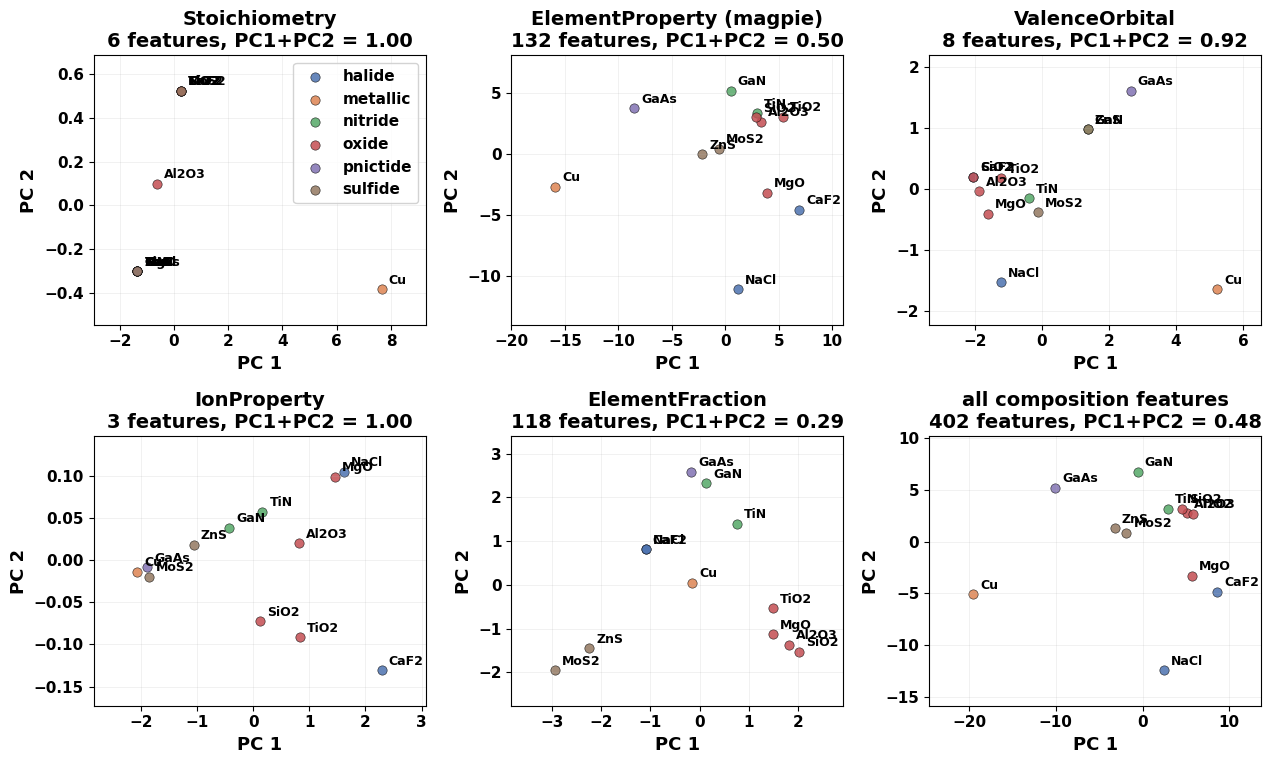

In [6]:
COMP_SINGLE = {
    "Stoichiometry": Stoichiometry(),
    "ElementProperty (magpie)": ElementProperty.from_preset("magpie"),
    "ValenceOrbital": ValenceOrbital(),
    "IonProperty": IonProperty(fast=True),
    "ElementFraction": ElementFraction(),
}
comp_all = MultipleFeaturizer(list(COMP_SINGLE.values()) + [Meredig()])

sets_comp = {}
for name, fz in COMP_SINGLE.items():
    X, _ = safe_featurize(fz, comps)
    sets_comp[name] = X
    print(f"  {name:26s} {X.shape[1]:4d} features")

X_comp_all, _ = safe_featurize(comp_all, comps)
sets_comp["all composition features"] = X_comp_all
print(f"  {'all of them concatenated':26s} {X_comp_all.shape[1]:4d} features")

fig, _ = pca_panels(sets_comp, fams, ncol=3, annot=COMP_SET)
plt.show()

In the `Stoichiometry` panel the twelve compositions land on only a few spots. MgO, ZnS,
NaCl, GaN, TiN and GaAs share one point, and TiO₂, SiO₂, MoS₂ and CaF₂ share another. This
featurizer only looks at norms of the atomic fractions, so every AB compound gets the same
value, and so does every AB₂ compound.

`ElementFraction` fills only the entries of the elements that are present, out of 118, so
most of its columns are zero and the two components carry the smallest fraction of the
variance of the six panels.

The last panel concatenates the five featurizers and `Meredig`. It has the most columns,
but the arrangement is close to the `magpie` panel and the fraction of variance in the two
components goes down rather than up. Adding columns takes away from what a single 2D
picture can hold.

## Part 3: Polymorphs — same composition, different structure

We read rutile, anatase and brookite from CIF files. All three are conventional standard
cells from the Materials Project.

| Polymorph | Materials Project | Space group |
|---|---|---|
| rutile | `mp-2657` | P4₂/mnm (136) |
| anatase | `mp-390` | I4₁/amd (141) |
| brookite | `mp-1840` | Pbca (61) |

In [7]:
NAMES = ["rutile", "anatase", "brookite"]
S = {n: Structure.from_file(CIF_DIR / f"TiO2_{n}.cif") for n in NAMES}

# --- (optional) fetch directly from the Materials Project API ---
# You need your own key from https://next-gen.materialsproject.org/api
# from mp_api.client import MPRester
# IDS = {"rutile": "mp-2657", "anatase": "mp-390", "brookite": "mp-1840"}
# with MPRester("YOUR_API_KEY") as mpr:
#     S = {k: SpacegroupAnalyzer(mpr.get_structure_by_material_id(v))
#             .get_conventional_standard_structure() for k, v in IDS.items()}

for n, st in S.items():
    print(f"{n:9s} {len(st):3d} sites   {st.composition.reduced_formula}")

rutile      6 sites   TiO2
anatase    12 sites   TiO2
brookite   24 sites   TiO2


Let us put the lattice constants and densities in a table.

In [8]:
rows = []
for name, st in S.items():
    sga = SpacegroupAnalyzer(st)
    rows.append({
        "polymorph": name,
        "formula": st.composition.reduced_formula,
        "spacegroup": sga.get_space_group_symbol(),
        "SG #": sga.get_space_group_number(),
        "crystal system": str(sga.get_crystal_system()),
        "nsites": len(st),
        "a (A)": round(st.lattice.a, 4),
        "c (A)": round(st.lattice.c, 4),
        "volume (A^3)": round(st.volume, 2),
        "vpa (A^3/atom)": round(st.volume / len(st), 4),
        "density (g/cm3)": round(float(st.density), 4),
    })
summary = pd.DataFrame(rows).set_index("polymorph")
summary

,formula,spacegroup,SG #,crystal system,nsites,a (A),c (A),volume (A^3),vpa (A^3/atom),density (g/cm3)
polymorph,,,,,,,,,,
rutile,TiO2,P4_2/mnm,136,tetragonal,6,4.5998,2.9592,62.61,10.4354,4.2362
anatase,TiO2,I4_1/amd,141,tetragonal,12,3.7825,9.6150,137.57,11.4640,3.8561
brookite,TiO2,Pbca,61,orthorhombic,24,5.1491,9.1942,258.45,10.7686,4.1052


The `formula` column reads `TiO2` on all three rows. The atom count of the unit cell is
6, 12 and 24, and the volume per atom is 10.44, 11.46 and 10.77 Å³.

That is the problem setting for this lesson. Seen through composition alone the three
materials are a single point, yet their properties differ: anatase is used as a
photocatalyst and rutile as a white pigment, and their refractive indices and band gaps
are different too.

mi-book Ch.8 puts the same situation this way.

> *"graphene, diamond, nanotubes, and buckyballs all have the same composition,
> but wildly different properties."*
> — Enze Chen & Mark Asta, *Review of matminer features*

### Looking at the 3D structures

All three polymorphs are built from TiO₆ octahedra, and what differs is how those
octahedra connect.

- rutile — octahedra share edges and form chains along the c axis.
- anatase — the octahedral connection is more twisted, stretching the c axis (c/a ≈ 2.5).
- brookite — orthorhombic, with the most irregular octahedral connectivity.

The cell below defines three plotting functions. If `py3Dmol` is available we use a
rotatable view; otherwise we fall back to ASE, and finally to a static matplotlib image.

In [9]:
# Per-element colour and radius (conventional CPK colours)
ELEM_STYLE = {
    "Ti": ("#BFC2C7", 0.60), "O": ("#FF0D0D", 0.30), "Si": ("#F0C8A0", 0.50),
    "C":  ("#404040", 0.35), "Zn": ("#7D80B0", 0.60), "S": ("#FFFF30", 0.45),
    "Li": ("#CC80FF", 0.55), "N": ("#3050F8", 0.30),
}


def show_3d_py3dmol(structs, width=280, height=300, supercell=(2, 2, 2)):
    """Draw rotatable, zoomable 3D structures side by side with py3Dmol.

    py3Dmol injects JS directly, so no widget manager is needed. The figure does not
    survive a notebook save in every viewer, so show_3d_static below is kept alongside it.
    """
    import py3Dmol
    n = len(structs)
    view = py3Dmol.view(width=width * n, height=height, viewergrid=(1, n))
    for j, (name, st) in enumerate(structs.items()):
        rep = st.copy()
        rep.make_supercell(supercell)
        view.addModel(rep.to(fmt="cif"), "cif", viewer=(0, j))
        view.setStyle({"sphere": {"scale": 0.30}, "stick": {"radius": 0.12}}, viewer=(0, j))
        view.addUnitCell(viewer=(0, j))
        view.zoomTo(viewer=(0, j))
    return view


def show_3d_static(structs, supercell=(1, 1, 1), figsize_per=3.6, elev=16, azim=24,
                   bond_cutoff=2.4):
    """Build a static 3D structure figure with matplotlib alone.

    Atoms are spheres, the unit cell is drawn as its 12 edges, and bonds between unlike
    elements are drawn with a distance cutoff. The neighbouring atoms outside the cell are
    drawn faintly as well, otherwise the bonds get cut off at the cell boundary.
    """
    names = list(structs)
    fig = plt.figure(figsize=(figsize_per * len(names), figsize_per + 0.4))
    for j, name in enumerate(names):
        st = structs[name].copy()
        st.make_supercell(supercell)
        ax = fig.add_subplot(1, len(names), j + 1, projection="3d")
        M = st.lattice.matrix
        corners = np.array([[i, k, l] for i in (0, 1) for k in (0, 1) for l in (0, 1)]) @ M
        for a in range(8):
            for b in range(a + 1, 8):
                fa = np.array([(a >> 2) & 1, (a >> 1) & 1, a & 1])
                fb = np.array([(b >> 2) & 1, (b >> 1) & 1, b & 1])
                if np.abs(fa - fb).sum() == 1:
                    ax.plot(*zip(corners[a], corners[b]), color="0.55", lw=0.7)
        ghost = {}
        for site in st:
            for nb in st.get_neighbors(site, r=bond_cutoff):
                if nb.specie.symbol == site.specie.symbol:
                    continue
                ax.plot(*zip(site.coords, nb.coords), color="0.30", lw=1.0, zorder=1)
                ghost.setdefault(nb.specie.symbol, []).append(nb.coords)
        for sym, pts in ghost.items():
            color, rad = ELEM_STYLE.get(sym, ("#909090", 0.45))
            pts = np.array(pts)
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=(rad * 150) ** 0.95,
                       color=color, alpha=0.35, edgecolor="none", zorder=2)
        for el in st.composition.elements:
            pts = np.array([site.coords for site in st if site.specie.symbol == el.symbol])
            color, rad = ELEM_STYLE.get(el.symbol, ("#909090", 0.45))
            ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=(rad * 190) ** 0.95,
                       color=color, edgecolor="black", linewidth=0.35,
                       depthshade=True, label=el.symbol, zorder=3)
        lo, hi = corners.min(axis=0) - 0.8, corners.max(axis=0) + 0.8
        ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
        ax.set_title(f"{name}\n{st.composition.reduced_formula}, "
                     f"{supercell[0]}x{supercell[1]}x{supercell[2]} cell", fontsize=13)
        ax.set_box_aspect((hi - lo))
        ax.view_init(elev=elev, azim=azim)
        ax.set_axis_off()
        ax.legend(fontsize=11, loc="upper right")
    fig.tight_layout()
    fig.subplots_adjust(top=0.86)
    return fig


def show_3d(structs, **kw):
    """Use whichever backend is available: py3Dmol -> ASE -> matplotlib."""
    try:
        view = show_3d_py3dmol(structs, **{k: v for k, v in kw.items()
                                           if k in ("width", "height", "supercell")})
        print("[3D] using py3Dmol -- you can rotate and zoom with the mouse.")
        return view.show()
    except ImportError:
        pass
    try:
        from ase.visualize.plot import plot_atoms
        from pymatgen.io.ase import AseAtomsAdaptor
        sc = kw.get("supercell", (2, 2, 2))
        fig, axes = plt.subplots(1, len(structs), figsize=(3.8 * len(structs), 3.8))
        for ax, (name, st) in zip(np.atleast_1d(axes), structs.items()):
            plot_atoms(AseAtomsAdaptor.get_atoms(st) * sc, ax, radii=0.4,
                       rotation="12x,14y,0z")
            ax.set_title(name, fontsize=13)
            ax.set_axis_off()
        fig.tight_layout()
        print("[3D] py3Dmol is missing, so a static ASE image was used.")
        return fig
    except ImportError:
        pass
    print("[3D] neither py3Dmol nor ASE is available, so a static matplotlib image was used.")
    return show_3d_static(structs, **{k: v for k, v in kw.items()
                                      if k in ("supercell", "figsize_per", "elev",
                                               "azim", "bond_cutoff")})

First a static image of the three structures. It also works without `py3Dmol`, and it
survives an export to PDF.

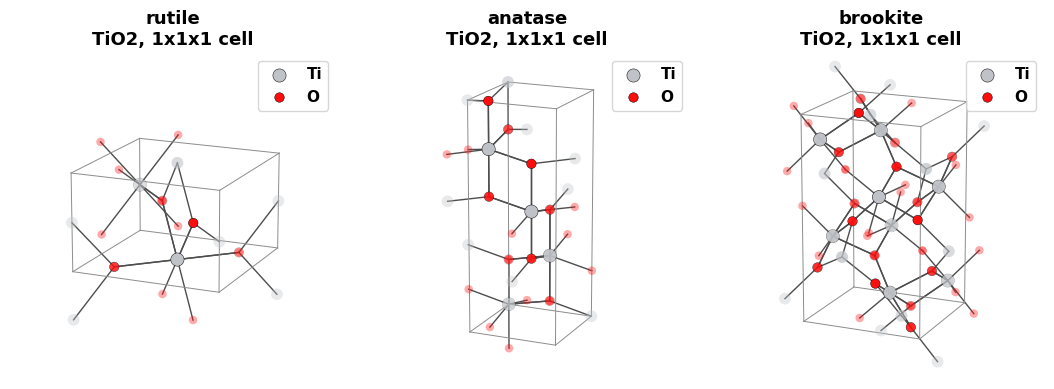

In [10]:
_ = show_3d_static(S, supercell=(1, 1, 1))

Now the same three structures with `py3Dmol`. **Drag with the mouse to rotate and scroll
to zoom.** The grey lines are the unit-cell edges.

The octahedral connectivity is easier to see in an enlarged cell, so the cell below is
drawn as 2×2×2. Change it to `supercell=(1, 1, 1)` for a single unit cell.

In [11]:
show_3d_py3dmol(S, width=300, height=320, supercell=(2, 2, 2)).show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

### Looking at the XRD patterns

XRD is the standard experimental way to distinguish polymorphs. The `XRDCalculator` in
`pymatgen` computes a powder XRD pattern from a structure. We use the Cu Kα line
(1.54184 Å).

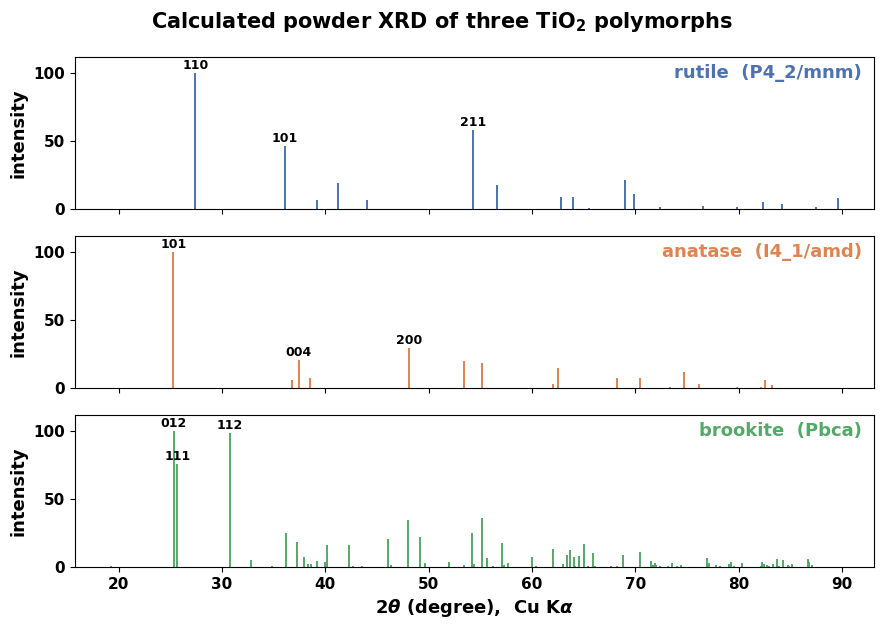

In [12]:
from pymatgen.analysis.diffraction.xrd import XRDCalculator

xrd = XRDCalculator(wavelength="CuKa")
patterns = {name: xrd.get_pattern(st, two_theta_range=(10, 90)) for name, st in S.items()}

fig, axes = plt.subplots(len(patterns), 1, figsize=(9, 6.4), sharex=True)
peak_rows = []
for ax, (name, p), color in zip(axes, patterns.items(), PALETTE):
    ax.vlines(p.x, 0, p.y, color=color, lw=1.4)
    ax.set_ylabel("intensity")
    ax.set_ylim(0, 112)
    ax.text(0.985, 0.86, f"{name}  ({summary.loc[name, 'spacegroup']})",
            transform=ax.transAxes, ha="right", fontsize=13, fontweight="bold", color=color)
    top = sorted(zip(p.x, p.y, p.hkls), key=lambda t: -t[1])[:3]
    for x, y, hkl in top:
        idx = hkl[0]["hkl"] if isinstance(hkl, list) else hkl["hkl"]
        ax.annotate(f"{''.join(str(abs(i)) for i in idx)}", (x, y),
                    textcoords="offset points", xytext=(0, 3), ha="center", fontsize=9)
        peak_rows.append({"polymorph": name, "2theta (deg)": round(x, 2),
                          "intensity": round(y, 1), "hkl": str(tuple(idx))})
axes[-1].set_xlabel(r"$2\theta$ (degree),  Cu K$\alpha$")
fig.suptitle("Calculated powder XRD of three TiO$_2$ polymorphs", fontsize=15)
fig.tight_layout()
plt.show()

Let us tabulate the three strongest peaks of each pattern. The anatase (101) at 25.3° and
the rutile (110) at 27.4° can be compared with the literature.

In [13]:
pd.DataFrame(peak_rows)

,polymorph,2theta (deg),intensity,hkl
0,rutile,27.42,100.0,"(1, 1, 0)"
1,rutile,54.31,58.4,"(2, 1, 1)"
2,rutile,36.09,46.2,"(1, 0, 1)"
3,anatase,25.30,100.0,"(1, 0, 1)"
4,anatase,48.11,29.0,"(2, 0, 0)"
5,anatase,37.41,20.7,"(0, 0, 4)"
6,brookite,25.33,100.0,"(0, 1, 2)"
7,brookite,30.79,98.3,"(1, 1, 2)"
8,brookite,25.68,75.6,"(1, 1, 1)"


The XRD pattern computed here comes back as a structure feature in Part 5. The
`XRDPowderPattern` featurizer runs the same calculation and returns it as a fixed-length
vector.

## Part 4: Composition features cannot tell the polymorphs apart

A composition featurizer only takes a `Composition`, and the `Composition` of rutile,
anatase and brookite is `TiO2` in all three cases, so the three inputs are identical to
begin with. Let us apply the 145 composition features to them.

In [14]:
structs = [S[n] for n in NAMES]
labels = np.array(NAMES)

comp_featurizer = MultipleFeaturizer([
    Stoichiometry(),
    ElementProperty.from_preset("magpie"),
    ValenceOrbital(props=["frac"]),
    IonProperty(fast=True),
])
X_comp = np.array([comp_featurizer.featurize(st.composition) for st in structs], dtype=float)
comp_labels = comp_featurizer.feature_labels()

print(f"composition feature matrix {X_comp.shape}")
print(f"distinct rows {len(np.unique(np.round(X_comp, 12), axis=0))} / {len(X_comp)},  "
      f"columns with variance {int((np.nanstd(X_comp, axis=0) > VAR_TOL).sum())} / "
      f"{X_comp.shape[1]},  largest column std {np.nanstd(X_comp, axis=0).max():.3e}")
print()
display(show_vector(X_comp, comp_labels, labels, head=6, tail=4))

composition feature matrix (3, 145)
distinct rows 1 / 3,  columns with variance 0 / 145,  largest column std 7.105e-15



,rutile,anatase,brookite
0-norm,2.0,2.0,2.0
2-norm,0.7454,0.7454,0.7454
3-norm,0.6934,0.6934,0.6934
5-norm,0.6708,0.6708,0.6708
7-norm,0.6674,0.6674,0.6674
10-norm,0.6667,0.6667,0.6667
... (135 more),...,...,...
frac f valence electrons,0.0,0.0,0.0
compound possible,1.0,1.0,1.0
max ionic char,0.5944,0.5944,0.5944


The three columns hold the same values. All 145 components agree, so in a 2D picture the
three points land on the same spot. No column varies, so PCA has no direction to project
onto, and here we simply take two of the composition features as the axes.

embed2d -> ValueError: only 0 column(s) vary (tol=1e-08, 145 columns in total). A 2D embedding cannot be built.



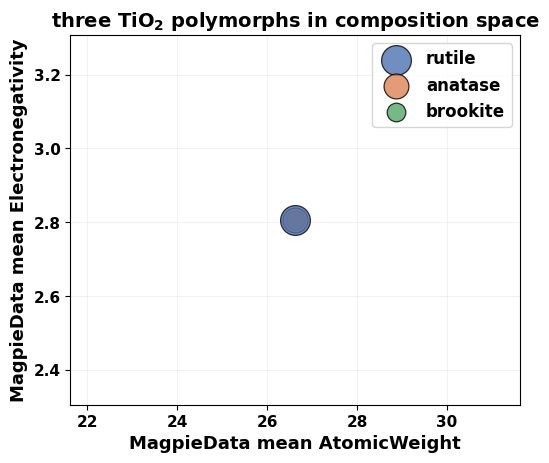

In [15]:
try:
    embed2d(X_comp)
except ValueError as err:
    print(f"embed2d -> ValueError: {err}")
print()


def find_col(sub, default):
    return next((i for i, lab in enumerate(comp_labels) if sub in lab), default)


ax_x, ax_y = find_col("mean AtomicWeight", 6), find_col("mean Electronegativity", 7)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
for i, name in enumerate(labels):
    ax.scatter(X_comp[i, ax_x], X_comp[i, ax_y], s=460 - 140 * i, alpha=0.8,
               color=PALETTE[i], edgecolor="black", linewidth=0.9, label=name, zorder=3 - i)
ax.set_xlim(X_comp[0, ax_x] - 5, X_comp[0, ax_x] + 5)
ax.set_ylim(X_comp[0, ax_y] - 0.5, X_comp[0, ax_y] + 0.5)
ax.set_xlabel(comp_labels[ax_x])
ax.set_ylabel(comp_labels[ax_y])
ax.set_title("three TiO$_2$ polymorphs in composition space", fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.25, lw=0.5)
plt.show()

The three markers overlap completely and read as one. In composition space the three
polymorphs are a single point.

## Part 5: Telling the polymorphs apart with structure features

A structure featurizer takes a `Structure`. It reads the lattice and the atomic positions
directly, so its values differ even when the composition is the same.

We start with the density. `DensityFeatures` returns three numbers: density, volume per
atom and packing fraction.

In [16]:
from matminer.featurizers.structure import (ChemicalOrdering, DensityFeatures,
                                            GlobalSymmetryFeatures, MaximumPackingEfficiency,
                                            RadialDistributionFunction, StructuralComplexity,
                                            StructuralHeterogeneity, XRDPowderPattern)
from matminer.featurizers.structure.sites import SiteStatsFingerprint

dens = DensityFeatures()
X_dens, _ = safe_featurize(dens, structs)
display(show_vector(X_dens, dens.feature_labels(), labels, head=3, tail=0))

,rutile,anatase,brookite
density,4.2362,3.8561,4.1052
vpa,10.4354,11.4640,10.7686
packing fraction,0.4250,0.3868,0.4118


The three values differ from polymorph to polymorph, in contrast with Part 4 where the
three columns of the composition features were identical.

Next comes the coordination geometry. `CrystalNNFingerprint` describes, for one atom, which
coordination polyhedron it sits in, as a set of order parameters. It returns a vector per
atom, so a statistic is needed to give every structure the same vector length, and
`SiteStatsFingerprint` does that.

In [17]:
ssf = SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops")
X_ssf, _ = safe_featurize(ssf, structs)
print(f"SiteStatsFingerprint(CrystalNN ops) -> {X_ssf.shape}")
print()

# Start from the features that differ the most across the three polymorphs.
order = np.argsort(np.nanstd(X_ssf, axis=0))[::-1][:8]
display(pd.DataFrame(X_ssf[:, order].T,
                     index=[ssf.feature_labels()[i] for i in order],
                     columns=labels).round(4))

SiteStatsFingerprint(CrystalNN ops) -> (3, 122)



,rutile,anatase,brookite
mean trigonal planar CN_3,0.3865,0.1461,0.2464
std_dev octahedral CN_6,0.4534,0.2620,0.3399
std_dev trigonal planar CN_3,0.2733,0.1033,0.2497
mean octahedral CN_6,0.3206,0.1852,0.2404
mean T-shaped CN_3,0.2534,0.3674,0.3188
std_dev T-shaped CN_3,0.1792,0.2598,0.2500
mean trigonal non-coplanar CN_3,0.1798,0.2461,0.2178
std_dev wt CN_3,0.4698,0.4548,0.4178


The order parameters named octahedral, tetrahedral and so on take different values in each
polymorph. All three TiO₂ polymorphs have six-coordinated Ti, but the octahedra are
distorted to different degrees, and that difference enters these values.

Whichever structure feature we use, the three polymorphs come apart. As an example we
project just the coordination-geometry feature to 2D.

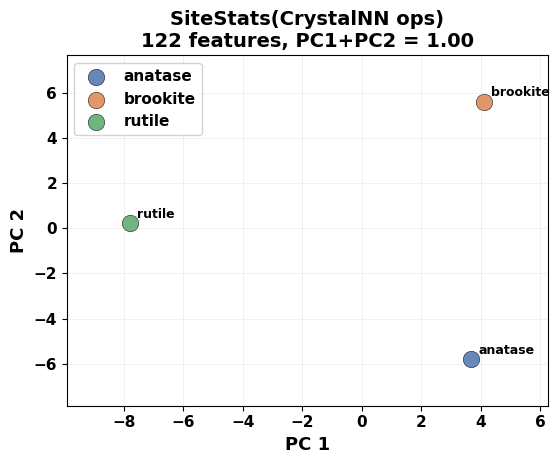

In [18]:
Z_ssf, n_kept, pca_ssf = embed2d(X_ssf, return_pca=True)

fig, ax = plt.subplots(figsize=(5.8, 4.8))
plot_by_group(Z_ssf, labels, ax=ax, annot=labels, s_pt=140,
              title=f"SiteStats(CrystalNN ops)\n{X_ssf.shape[1]} features, "
                    f"PC1+PC2 = {pca_ssf.explained_variance_ratio_.sum():.2f}")
plt.tight_layout()
plt.show()

The three points sit apart. With composition features they were a single point.

With only three points the 2D projection carries the original arrangement exactly, because
three points always lie in a plane. That is what a PC1+PC2 of 1.00 means.

## Part 6: How well structure features express three crystal-structure prototypes

Up to Part 5 the composition was the same and the structure differed. Now we go the other
way. Materials whose compositions differ but whose crystal structure is the same are put in
one group, and we prepared three such groups, picked from Materials Project by space group.

| group | prototype | space group | formula |
|---|---|---|---|
| rutile | TiO₂ type | `P4_2/mnm` (136) | AB₂ |
| perovskite | SrTiO₃ type | `Pm-3m` (221) | ABO₃ |
| spinel | MgAl₂O₄ type | `Fd-3m` (227) | AB₂O₄ |

Five per group, fifteen in total. If structure features read the crystal structure, the five
members of a group should sit close together and the groups should sit apart.

In [19]:
proto = pd.read_csv(DATA_DIR / "proto_index.csv")
P = [Structure.from_file(CIF_DIR / f) for f in proto["file"]]
proto_group = proto["group"].to_numpy()
proto_label = proto["label"].to_numpy()

display(proto[["group", "label", "material_id", "spacegroup", "nsites", "vpa", "density"]])

,group,label,material_id,spacegroup,nsites,vpa,density
0,rutile,TiO2,mp-2657,P4_2/mnm,12,10.4354,4.2362
1,rutile,SnO2,mp-856,P4_2/mnm,6,12.1369,6.8732
2,rutile,GeO2,mp-470,P4_2/mnm,6,9.3340,6.2051
3,rutile,RuO2,mp-825,P4_2/mnm,6,10.4193,7.0691
4,rutile,IrO2,mp-2723,P4_2/mnm,6,10.7467,11.5483
5,perovskite,SrTiO3,mp-5229,Pm-3m,5,11.9801,5.0865
6,perovskite,BaTiO3,mp-2998,Pm-3m,10,12.8739,6.0157
7,perovskite,KNbO3,mp-935811,Pm-3m,5,13.0822,4.5696
8,perovskite,KTaO3,mp-3614,Pm-3m,5,12.7509,6.9814
9,perovskite,BaZrO3,mp-3834,Pm-3m,5,14.9491,6.1438


Same layout as Part 5. The first five panels are one structure featurizer each, and the
last panel is those five plus `MaximumPackingEfficiency`, `StructuralComplexity` and
`ChemicalOrdering`, all concatenated. The colour is the group.

  DensityFeatures                  3 features   0 failed


  GlobalSymmetryFeatures           3 features   0 failed


  StructuralHeterogeneity          9 features   0 failed


  SiteStats(CrystalNN ops)       122 features   0 failed


  XRDPowderPattern               128 features   0 failed


  all of them concatenated       271 features   0 failed


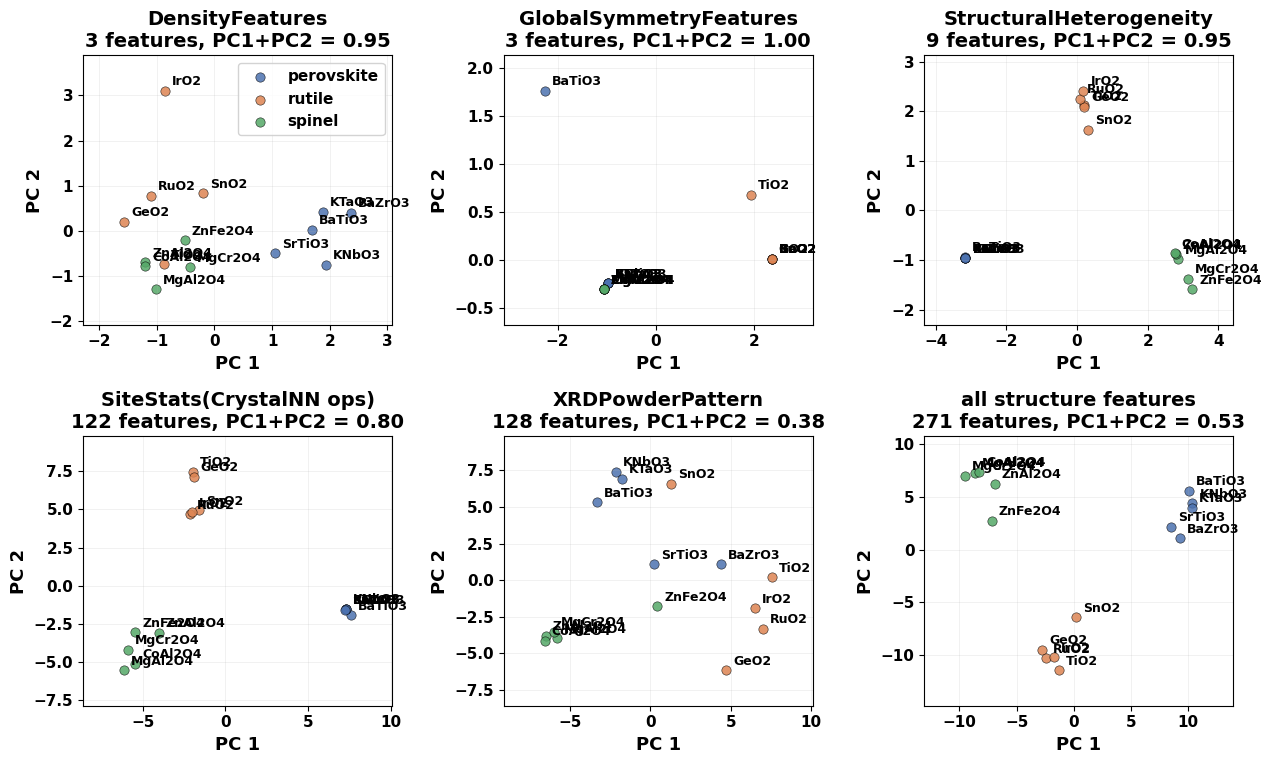

In [20]:
PROTO_SINGLE = {
    "DensityFeatures": DensityFeatures(),
    # crystal_system is a string and is_centrosymmetric is a bool, so take the numeric ones.
    "GlobalSymmetryFeatures": GlobalSymmetryFeatures(
        desired_features=["spacegroup_num", "crystal_system_int", "n_symmetry_ops"]),
    "StructuralHeterogeneity": StructuralHeterogeneity(),
    "SiteStats(CrystalNN ops)": SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops"),
    "XRDPowderPattern": XRDPowderPattern(),
}
proto_all = MultipleFeaturizer(list(PROTO_SINGLE.values()) +
                               [MaximumPackingEfficiency(), StructuralComplexity(),
                                ChemicalOrdering()])

sets_proto = {}
for name, fz in PROTO_SINGLE.items():
    X, n_failed = safe_featurize(fz, P)
    sets_proto[name] = X
    print(f"  {name:28s} {X.shape[1]:5d} features   {n_failed} failed")

X_proto_all, n_failed = safe_featurize(proto_all, P)
sets_proto["all structure features"] = X_proto_all
print(f"  {'all of them concatenated':28s} {X_proto_all.shape[1]:5d} features   "
      f"{n_failed} failed")

fig, _ = pca_panels(sets_proto, proto_group, ncol=3, annot=proto_label)
plt.show()

The fifteen materials are arranged differently in every panel.

- In `StructuralHeterogeneity` and `SiteStats(CrystalNN ops)` the three groups gather and
  sit apart from one another. Those featurizers read the spread of the Voronoi volumes and
  the shape of the coordination polyhedra.
- In `DensityFeatures` the five rutile-type materials spread out and TiO₂ ends up inside
  the spinel group. Density and volume per atom depend on which metal is present.
- In `GlobalSymmetryFeatures` the five perovskites and the five spinels sit on top of each
  other.
- `XRDPowderPattern` has 128 features, yet its two components carry the smallest fraction
  of the variance of the six panels, 0.38, and the groups mix.
- The last panel, everything concatenated, also separates the three groups, but its
  fraction of variance is 0.53, below the 0.80 of `SiteStats(CrystalNN ops)` alone.

## Part 7: 100 materials seen through composition + structure features

So far we looked at 3, 12 and 15 materials. Finally we apply the same features to 100
Materials Project entries. They cover six composition families and all seven crystal
systems.

The structures are in `data/mp100_structures.json.gz` and the index is in
`data/mp100_index.csv`. The download code is `data/fetch_02_sets.py`.

In [21]:
from monty.serialization import loadfn

mp = pd.read_csv(DATA_DIR / "mp100_index.csv")
S100 = loadfn(str(DATA_DIR / "mp100_structures.json.gz"))

print(f"{len(S100)} entries, {min(len(s) for s in S100)} to "
      f"{max(len(s) for s in S100)} atoms")
print("families      :", dict(mp["family"].value_counts()))
print("crystal system:", dict(mp["crystal_system"].value_counts()))
display(mp.head(6))

100 entries, 1 to 40 atoms
families      : {'oxide': np.int64(32), 'metallic': np.int64(25), 'sulfide': np.int64(15), 'halide': np.int64(13), 'pnictide': np.int64(8), 'nitride': np.int64(7)}
crystal system: {'Cubic': np.int64(43), 'Hexagonal': np.int64(16), 'Trigonal': np.int64(14), 'Tetragonal': np.int64(9), 'Monoclinic': np.int64(8), 'Orthorhombic': np.int64(8), 'Triclinic': np.int64(2)}


,family,material_id,formula,spacegroup,spacegroup_number,crystal_system,nsites,vpa,density,e_hull
0,halide,mp-22922,AgCl,Fm-3m,225,Cubic,2,21.3153,5.5826,0.0
1,halide,mp-1029,BaF2,Fm-3m,225,Cubic,3,20.1090,4.8259,0.0
2,halide,mp-2741,CaF2,Fm-3m,225,Cubic,3,13.9863,3.0898,0.0
3,halide,mp-22865,CsCl,Pm-3m,221,Cubic,2,35.5741,3.9293,0.0
4,halide,mp-614603,CsI,Fm-3m,225,Cubic,2,59.5512,3.6223,0.0
5,halide,mp-23251,KBr,Fm-3m,225,Cubic,2,35.7589,2.7631,0.0


We compute the 145 composition features and the structure features separately, and check
once more how many numbers one CIF turns into.

In [22]:
struct_fz = MultipleFeaturizer([DensityFeatures(), MaximumPackingEfficiency(),
                                SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops")])

X100_comp, _ = safe_featurize(comp_featurizer, [s.composition for s in S100])
X100_struct, n_failed = safe_featurize(struct_fz, S100)
X100_both = np.hstack([X100_comp, X100_struct])

print(f"composition features : {X100_comp.shape}")
print(f"structure features   : {X100_struct.shape}   {n_failed} structures failed")
print(f"composition + structure : {X100_both.shape}")
print()
display(show_vector(X100_both[:5], comp_featurizer.feature_labels() + struct_fz.feature_labels(),
                    mp["formula"].to_numpy()[:5], head=5, tail=5))

composition features : (100, 145)
structure features   : (100, 126)   0 structures failed
composition + structure : (100, 271)



,AgCl,BaF2,CaF2,CsCl,CsI
0-norm,2.0,2.0,2.0,2.0,2.0
2-norm,0.7071,0.7454,0.7454,0.7071,0.7071
3-norm,0.63,0.6934,0.6934,0.63,0.63
5-norm,0.5743,0.6708,0.6708,0.5743,0.5743
7-norm,0.552,0.6674,0.6674,0.552,0.552
... (261 more),...,...,...,...,...
std_dev wt CN_22,0.0,0.0,0.0,0.0,0.0
mean wt CN_23,0.0,0.0,0.0,0.0,0.0
std_dev wt CN_23,0.0,0.0,0.0,0.0,0.0
mean wt CN_24,0.0,0.0,0.0,0.0,0.0


We project the 100 materials to 2D with the composition features alone, the structure
features alone, and the two together. What we want to see here is whether the 100 materials
keep their own places instead of piling up on each other, so the points are drawn without
any grouping.

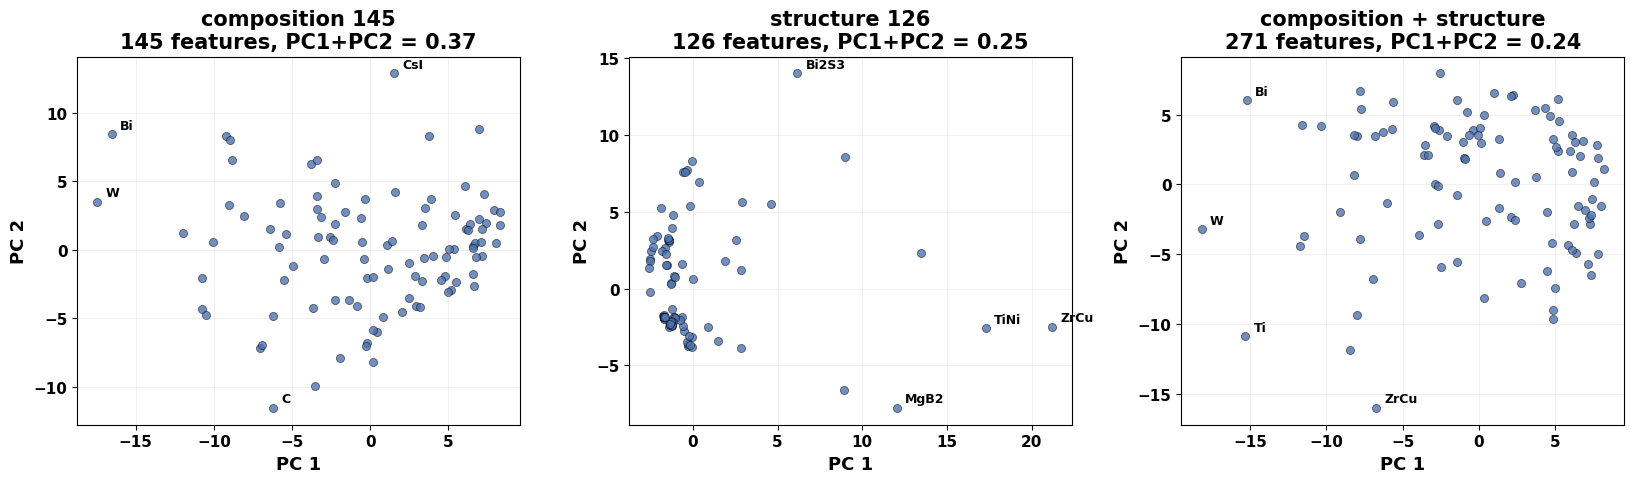

In [23]:
SETS100 = {"composition 145": X100_comp,
           "structure 126": X100_struct,
           "composition + structure": X100_both}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.0))
for ax, (name, X) in zip(axes, SETS100.items()):
    Z, n_kept, pca = embed2d(X, return_pca=True)
    ev = pca.explained_variance_ratio_.sum()
    ax.scatter(Z[:, 0], Z[:, 1], s=34, color="#4C72B0", alpha=0.8,
               edgecolor="black", linewidth=0.4)
    # Label only the four points furthest from the centre; 100 labels would be unreadable.
    for i in np.argsort(-np.linalg.norm(Z, axis=1))[:4]:
        ax.annotate(mp["formula"][i], (Z[i, 0], Z[i, 1]), fontsize=9,
                    textcoords="offset points", xytext=(6, 4))
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    ax.set_title(f"{name}\n{X.shape[1]} features, PC1+PC2 = {ev:.2f}", fontsize=15)
    ax.grid(alpha=0.25, lw=0.5)
plt.tight_layout()
plt.show()

In the middle panel, structure features alone, a large part of the 100 materials piles up
in one clump on the left. A few entries that run far out — ZrCu, TiNi, MgB₂, Bi₂S₃ — pull
the axes. Their coordination numbers are close to 12, so their coordination-geometry order
parameters are distributed differently from the oxides.

In the left panel, composition features alone, the points spread out fairly evenly, because
different compositions give different values.

In the right panel, the two together, the 100 materials each keep their own place. The
composition side pulls apart the clump left by the structure features.

The two components carry between 0.24 and 0.37 of the variance in the three panels.
Compared with the 0.79 of the fifteen prototypes, the more materials there are and the more
varied they are, the less a single 2D picture can hold. Two points that look close in this
figure are not necessarily close in the 271-dimensional space.

## Part 8: Try it yourself — polymorphs of another composition

Everything done with the three TiO₂ polymorphs, applied to another composition.
`data/cif/index.csv` holds three more compositions with several polymorphs each.

| composition | polymorphs | which ones |
|---|---|---|
| `SiO2` | 6 | alpha-quartz, quartz-enantiomorph, coesite, alpha-cristobalite, beta-cristobalite, stishovite |
| `C` | 4 | diamond, graphite-hex, graphite-rhomb, expanded-layered |
| `ZnS` | 4 | zincblende, wurtzite, polytype-R3m, polytype-P3m1 |

`CHOICE` below is left empty on purpose. Set it to one of these and the same procedure runs on that composition.

In [ ]:
CHOICE = ""          # <- pick one: "SiO2", "C" or "ZnS"

index = pd.read_csv(CIF_DIR / "index.csv")
counts = index["formula"].value_counts()
OPTIONS = sorted(counts[counts > 1].index)
if CHOICE not in OPTIONS:
    raise ValueError(f"Set CHOICE to one of {OPTIONS}, then run this cell again.")

picked = index[index["formula"] == CHOICE].reset_index(drop=True)
S_task = [Structure.from_file(CIF_DIR / f) for f in picked["file"]]
labels_task = picked["polymorph"].to_numpy()

print(f"{CHOICE}: {len(S_task)} polymorphs")
display(picked[["polymorph", "material_id", "spacegroup", "nsites", "vpa", "density"]])

Composition features first. Polymorphs share a composition, so the result should look like
Part 4.

In [ ]:
X_task_comp = np.array([comp_featurizer.featurize(st.composition) for st in S_task],
                       dtype=float)

print(f"composition feature matrix {X_task_comp.shape}")
print(f"distinct rows {len(np.unique(np.round(X_task_comp, 12), axis=0))} / "
      f"{len(X_task_comp)},  columns with variance "
      f"{int((np.nanstd(X_task_comp, axis=0) > VAR_TOL).sum())} / {X_task_comp.shape[1]},  "
      f"largest column std {np.nanstd(X_task_comp, axis=0).max():.3e}")

try:
    embed2d(X_task_comp)
except ValueError as err:
    print(f"embed2d -> ValueError: {err}")

However many polymorphs we add, composition features put them on one point.

Before the structure features, the polymorphs of the chosen composition drawn the way
Part 3 drew TiO₂. The static image first, three structures per row. For a composition
with few atoms in the unit cell, such as `C`, it is better to raise `supercell` to
`(2, 2, 2)`.

In [ ]:
S_task_dict = dict(zip(labels_task, S_task))
task_items = list(S_task_dict.items())

for i in range(0, len(task_items), 3):        # three structures per row
    show_3d_static(dict(task_items[i:i + 3]), supercell=(1, 1, 1))

The same polymorphs again with `py3Dmol`. **Drag with the mouse to rotate and scroll to
zoom.** The cells are drawn as 2×2×2, as in Part 3.

In [ ]:
for i in range(0, len(task_items), 3):
    show_3d_py3dmol(dict(task_items[i:i + 3]), width=300, height=320,
                    supercell=(2, 2, 2)).show()

Now the structure features — the same coordination-geometry feature used in Part 5.

In [ ]:
X_task_struct, n_failed = safe_featurize(
    SiteStatsFingerprint.from_preset("CrystalNNFingerprint_ops"), S_task)
Z_task, n_kept, pca_task = embed2d(X_task_struct, return_pca=True)

print(f"structure feature matrix {X_task_struct.shape}, {n_kept} columns with variance, "
      f"{n_failed} structures failed")

fig, ax = plt.subplots(figsize=(6.4, 5.2))
plot_by_group(Z_task, labels_task, ax=ax, annot=labels_task, s_pt=140, legend=False,
              title=f"{CHOICE} polymorphs — SiteStats(CrystalNN ops)\n"
                    f"{X_task_struct.shape[1]} features, "
                    f"PC1+PC2 = {pca_task.explained_variance_ratio_.sum():.2f}")
plt.tight_layout()
plt.show()

Run with `SiO2` and the six polymorphs come apart in 2D, with the two components carrying
0.95 of the variance.

alpha-quartz and quartz-enantiomorph are an enantiomorphic pair and land almost on the same
spot: the table gives them the space groups `P3_121` and `P3_221` and volumes per atom of
12.625 and 12.634. stishovite has the same space group as rutile, `P4_2/mnm`, and a volume
per atom of 8.044 Å³ against 12.6 to 15.0 for the other five, so it sits far away.

Change `CHOICE` to `"C"` and diamond separates from the graphite-like ones, with hexagonal
and rhombohedral graphite close together. Change it to `"ZnS"` and the four have volumes per
atom of 19.543 to 19.555 — polytypes, and the hardest case.

## References and citations

- **matminer** — <https://hackingmaterials.lbl.gov/matminer/> (LBNL Hacking Materials).
  Every featurizer and preset name used here.
- **matminer-notes** (`codes/matminer-notes.ipynb`) — the shape and the voice of this
  notebook.
- **py3Dmol / 3Dmol.js** — the rotatable 3D structures in Parts 3 and 8.
- **Materials Project** (CC BY 4.0) — every crystal structure in `data/cif/`,
  `data/proto_index.csv` and `data/mp100_*`. The download code is `data/fetch_from_mp.py`
  and `data/fetch_02_sets.py`.

Original papers. The source of each individual featurizer can also be read off with
`citations()`.

- L. Ward *et al.*, *Comput. Mater. Sci.* **152**, 60 (2018) — matminer
- S. P. Ong *et al.*, *Comput. Mater. Sci.* **68**, 314 (2013) — pymatgen, and the XRD
  calculation inside `XRDPowderPattern`
- L. Ward *et al.*, *npj Comput. Mater.* **2**, 16028 (2016) — the Magpie composition
  features (`Stoichiometry`, `ElementProperty`, `ValenceOrbital`, `IonProperty`)
- A. M. Deml *et al.*, *Phys. Rev. B* **93**, 085142 (2016) — `ValenceOrbital`
- B. Meredig *et al.*, *Phys. Rev. B* **89**, 094104 (2014) — `Meredig`
- L. Ward *et al.*, *Phys. Rev. B* **96**, 024104 (2017) — the Voronoi-based structure
  features (`MaximumPackingEfficiency`, `ChemicalOrdering`, `StructuralHeterogeneity`)
- S. V. Krivovichev, *Mineral. Mag.* **77**, 275 (2013) — `StructuralComplexity`
- N. E. R. Zimmermann & A. Jain, *RSC Adv.* **10**, 6063 (2020) — the coordination-geometry
  order parameters behind `CrystalNNFingerprint`
- N. Rego & D. Koes, *Bioinformatics* **31**, 1322 (2015) — 3Dmol.js